# Driver Style Analysis and Integration

## Objective

The objective of this notebook is to analyze driver-specific tyre management characteristics from historical Formula 1 race data.

A Driver Tyre Management Score is computed for every driver using multiple performance metrics including tyre degradation, average tyre life, lap performance, and race position.

The drivers are then grouped into different driving styles using K-Means clustering. These driver profiles will later be integrated into the machine learning pipeline to create a driver-aware race strategy prediction system.

### Outputs

- Driver Performance Statistics
- Driver Tyre Management Score
- Driver Driving Style Clusters
- Driver Profiles
- Research Figures
- driver_profiles.csv

In [5]:
import fastf1
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [6]:
fastf1.Cache.enable_cache("../data/f1_cache")

In [7]:
# defining races and sesasons

years = [2022, 2023, 2024]
races = [
    "Bahrain",
    "Spain",
    "Monza",
    "Singapore"
]

In [8]:
# empty list for telemtry features

driver_profiles = []

In [9]:
# starting looping through every race

for year in years:

    for race in races:

        print(f"\nLoading {year} {race}...")

        session = fastf1.get_session(
            year,
            race,
            "R"
        )

        session.load()




Loading 2022 Bahrain...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', 


Loading 2022 Spain...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '63', '55', '44', '77', '31', '4', '14', '22', '5', '3', '10', '47', '18', '6', '20', '23', '24', '16']
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info



Loading 2022 Monza...


...

req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 1 completed the race distance 00:00.015000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '44', '63', '16', '55', '81', '11', '10', '31', '27', '14', '24', '18', '3', '77', '20', '23', '22', '2']
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req   


Loading 2024 Monza...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']
core           INFO 	Loading data for Singapore Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info



Loading 2024 Singapore...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '81', '63', '16', '44', '55', '14', '27', '11', '43', '22', '31', '18', '24', '77', '10', '3', '20', '23']


In [29]:
# ============================================================
# Extract telemetry-based behavioural features
# One row = One Driver in One Race
# ============================================================

driver_profiles = []

for year in years:

    for race in races:

        print(f"\nProcessing {year} {race}...")

        try:
            session = fastf1.get_session(year, race, "R")
            session.load()
        except Exception as e:
            print(f"Skipping {year} {race}: {e}")
            continue

        laps = session.laps.pick_quicklaps()

        # ---------------------------------------------
        # Loop over every driver
        # ---------------------------------------------
        for driver_code in laps["Driver"].unique():

            driver_laps = laps.pick_drivers(driver_code)

            throttle_mean = []
            throttle_smoothness = []
            brake_ratio = []
            brake_events = []
            corner_speed = []
            top_speed = []
            gear_changes = []

            # -----------------------------------------
            # Loop over every lap of this driver
            # -----------------------------------------
            for _, lap in driver_laps.iterlaps():

                try:
                    telemetry = lap.get_car_data().add_distance()

                    if telemetry.empty:
                        continue

                    # -------------------------------
                    # Mean Throttle
                    # -------------------------------
                    throttle = telemetry["Throttle"].values
                    throttle_mean.append(np.mean(throttle))

                    # -------------------------------
                    # Throttle Smoothness
                    # -------------------------------
                    throttle_smoothness.append(
                        np.std(np.diff(throttle))
                    )

                    # -------------------------------
                    # Brake Ratio
                    # -------------------------------
                    brake = telemetry["Brake"].astype(int).values
                    brake_ratio.append(np.mean(brake))

                    # -------------------------------
                    # Brake Events
                    # -------------------------------
                    brake_events.append(
                        np.sum(np.diff(brake) == 1)
                    )

                    # -------------------------------
                    # Corner Speed
                    # Approximation:
                    # Speed while throttle < 30%
                    # -------------------------------
                    speed = telemetry["Speed"].values

                    corner_mask = throttle < 30

                    if np.any(corner_mask):
                        corner_speed.append(
                            np.mean(speed[corner_mask])
                        )

                    # -------------------------------
                    # 95th Percentile Top Speed
                    # -------------------------------
                    top_speed.append(
                        np.percentile(speed, 95)
                    )

                    # -------------------------------
                    # Gear Change Rate
                    # -------------------------------
                    gears = telemetry["nGear"].values

                    gear_changes.append(
                        np.sum(np.diff(gears) != 0)
                    )

                except Exception:
                    continue

            # -----------------------------------------
            # Skip drivers with no valid laps
            # -----------------------------------------
            if len(throttle_mean) == 0:
                continue

            # -----------------------------------------
            # Create ONE profile for this driver
            # -----------------------------------------
            driver_profiles.append({

                "Year": year,
                "Race": race,
                "Driver": driver_code,

                "MeanThrottle": np.mean(throttle_mean),

                "ThrottleSmoothness": np.mean(
                    throttle_smoothness
                ),

                "BrakeRatio": np.mean(
                    brake_ratio
                ),

                "BrakeEvents": np.mean(
                    brake_events
                ),

                "CornerSpeed": np.mean(
                    corner_speed
                ),

                "TopSpeed95": np.mean(
                    top_speed
                ),

                "GearChangeRate": np.mean(
                    gear_changes
                )

            })

# ============================================================
# Convert to DataFrame
# ============================================================

driver_profiles = pd.DataFrame(driver_profiles)

print("\nDriver Profiles Shape:")
print(driver_profiles.shape)

display(driver_profiles.head())


Processing 2022 Bahrain...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', 


Processing 2022 Spain...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '63', '55', '44', '77', '31', '4', '14', '22', '5', '3', '10', '47', '18', '6', '20', '23', '24', '16']
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...



Processing 2022 Monza...


...

req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']
core           INFO 	Loading data for Singapore Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...



Processing 2024 Singapore...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '81', '63', '16', '44', '55', '14', '27', '11', '43', '22', '31', '18', '24', '77', '10', '3', '20', '23']



Driver Profiles Shape:
(230, 10)


,Year,Race,Driver,MeanThrottle,ThrottleSmoothness,BrakeRatio,BrakeEvents,CornerSpeed,TopSpeed95,GearChangeRate
0,2022,Bahrain,VER,62.578711,15.645198,0.211504,8.116279,158.632106,292.587209,51.139535
1,2022,Bahrain,GAS,63.901076,14.995063,0.192652,8.027027,154.716815,290.675676,43.270270
2,2022,Bahrain,PER,63.029007,15.476567,0.216826,8.045455,156.222082,292.984091,49.590909
3,2022,Bahrain,ALO,65.301901,15.852379,0.220214,8.268293,150.816173,291.743902,52.780488
4,2022,Bahrain,LEC,68.037786,14.784752,0.207480,8.437500,154.155078,289.237500,51.166667


In [30]:
print(driver_profiles.shape)
print(driver_profiles["Driver"].nunique())

(230, 10)
26


In [31]:
# select features

feature_cols = [
    "MeanThrottle",
    "ThrottleSmoothness",
    "BrakeRatio",
    "BrakeEvents",
    "CornerSpeed",
    "TopSpeed95",
    "GearChangeRate"
]

X = driver_profiles[feature_cols]

In [32]:
# normalizing the features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(230, 7)


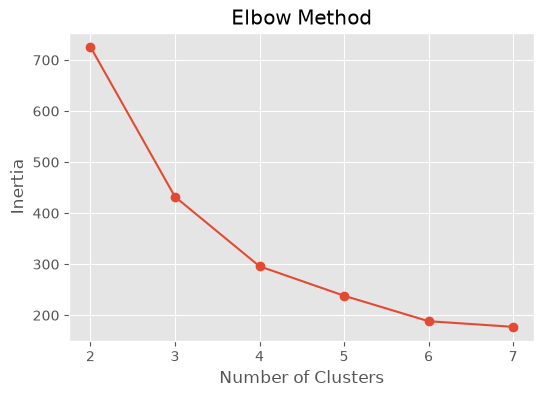

In [33]:
# finding the best k (elbow method)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(2, 8)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [34]:
# silhouette score

from sklearn.metrics import silhouette_score

for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}  Silhouette Score={score:.3f}")

K=2  Silhouette Score=0.468
K=3  Silhouette Score=0.449
K=4  Silhouette Score=0.477
K=5  Silhouette Score=0.482
K=6  Silhouette Score=0.493
K=7  Silhouette Score=0.449


In [35]:
# final k-means

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

driver_profiles["DrivingStyleCluster"] = kmeans.fit_predict(X_scaled)

driver_profiles.head()

,Year,Race,Driver,MeanThrottle,ThrottleSmoothness,BrakeRatio,BrakeEvents,CornerSpeed,TopSpeed95,GearChangeRate,DrivingStyleCluster
0,2022,Bahrain,VER,62.578711,15.645198,0.211504,8.116279,158.632106,292.587209,51.139535,0
1,2022,Bahrain,GAS,63.901076,14.995063,0.192652,8.027027,154.716815,290.675676,43.270270,0
2,2022,Bahrain,PER,63.029007,15.476567,0.216826,8.045455,156.222082,292.984091,49.590909,0
3,2022,Bahrain,ALO,65.301901,15.852379,0.220214,8.268293,150.816173,291.743902,52.780488,0
4,2022,Bahrain,LEC,68.037786,14.784752,0.207480,8.437500,154.155078,289.237500,51.166667,0


In [36]:
# cluster summary

cluster_summary = (
    driver_profiles
    .groupby("DrivingStyleCluster")[feature_cols]
    .mean()
    .round(2)
)

display(cluster_summary)

,MeanThrottle,ThrottleSmoothness,BrakeRatio,BrakeEvents,CornerSpeed,TopSpeed95,GearChangeRate
DrivingStyleCluster,,,,,,,
0,63.58,15.11,0.21,8.25,152.86,295.09,46.25
1,73.63,14.47,0.15,6.61,177.91,326.57,34.58
2,55.71,17.28,0.25,12.21,148.07,283.82,49.35
3,65.44,16.13,0.18,7.07,169.11,303.76,31.03
4,51.38,18.74,0.27,16.18,131.90,277.34,53.66
5,57.84,16.59,0.22,9.42,154.09,294.21,34.70


In [40]:
cluster_names = {
    0: "Balanced Driver",
    1: "High-Speed Aggressive Driver",
    2: "Technical Driver",
    3: "Fast & Efficient Driver",
    4: "Conservative Driver",
    5: "Smooth Driver"
}

driver_profiles["DrivingStyle"] = (
    driver_profiles["DrivingStyleCluster"]
    .map(cluster_names)
)

driver_profiles.head()

,Year,Race,Driver,MeanThrottle,ThrottleSmoothness,BrakeRatio,BrakeEvents,CornerSpeed,TopSpeed95,GearChangeRate,DrivingStyleCluster,DrivingStyle
0,2022,Bahrain,VER,62.578711,15.645198,0.211504,8.116279,158.632106,292.587209,51.139535,0,Balanced Driver
1,2022,Bahrain,GAS,63.901076,14.995063,0.192652,8.027027,154.716815,290.675676,43.270270,0,Balanced Driver
2,2022,Bahrain,PER,63.029007,15.476567,0.216826,8.045455,156.222082,292.984091,49.590909,0,Balanced Driver
3,2022,Bahrain,ALO,65.301901,15.852379,0.220214,8.268293,150.816173,291.743902,52.780488,0,Balanced Driver
4,2022,Bahrain,LEC,68.037786,14.784752,0.207480,8.437500,154.155078,289.237500,51.166667,0,Balanced Driver


In [41]:
# saving the file

output_path = "../data/processed/driver_profiles_with_clusters.csv"
driver_profiles.to_csv(output_path, index=False)

print("Saved successfully!")
print(output_path)

Saved successfully!
../data/processed/driver_profiles_with_clusters.csv


In [43]:
print(driver_profiles["DrivingStyle"].value_counts())

DrivingStyle
Balanced Driver                 59
High-Speed Aggressive Driver    59
Fast & Efficient Driver         40
Technical Driver                37
Smooth Driver                   21
Conservative Driver             14
Name: count, dtype: int64
